# `csl.py`

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import gbtk.csl as csl
import pandas as pd
import numpy as np

## Constructing a CSL
The following code instantiates a `csl` object with fcc lattice type:

In [2]:
test_csl = csl.CSL('fcc')

To obtain some useful feedback we will switch on the debug information for this csl:

In [3]:
test_csl.set_debug()

We now use `h,k,l` to specify the misorientation axis and a pair of integers `m,n` to define the axis:

In [4]:
h = 1; k = 1; l = 1
m = 1; n = 5

We can then use one of the helper functions to obtain the misorientation angle corresponding to `m,n` for axis `h,k,l`:

In [5]:
theta = csl.calculate_theta(h,k,l,m,n)
print(180*theta/np.pi)

38.213210701738184


Note that another helper function will give us the $\Sigma$ value for this boundary:

In [6]:
print(csl.calculate_sigma(h,k,l,m,n))

7.0


We now use a couple of accessor functions to set the axis and angle of our csl:

In [7]:
test_csl.set_axis([h,k,l])
test_csl.set_angle(theta)

Actually, we can avoid the need to fisrt calculate `theta` and instead set the misorientation angle directly with an alternative method:

In [8]:
test_csl.set_angle_mn(m,n)

Now we want to do something useful. The code below does the following:
* Calculates the rotation matrix for our axis-angle combination
* Sets up the functionality required to search for a csl unit cell (using functionality in `spatialsearch.py`)
* Finds the csl basis
Because we have switched on the debug output we will get some useful feedback?

In [9]:
test_csl.find_misorientation_rotation_matrix()
test_csl.enable_search()
test_csl.find_csl_basis()

----------------------------------------------------
csl.find_csl_basis() debug:
***************************
CSL Cell vectors (lattice basis)
Black                      White
[      1      1      1 ]   [      1      1      1 ]
[      0      1     -2 ]   [      1      0     -2 ]
[     -1      2      0 ]   [      0      2     -1 ]
CSL Cell vectors (cartesian basis)
Black                                       White
[     1.000000     1.000000     1.000000]   [     1.000000     1.000000     1.000000 ]
[     0.000000     1.000000    -2.000000]   [     1.000000     0.000000    -2.000000 ]
[    -1.000000     2.000000     0.000000]   [     0.000000     2.000000    -1.000000 ]



## Visualising the CSL 

At this stage we can use some of the visualisation tools to see what we have produced. First a look at the two csl unit cells in their original orientation:

----------------------------------------------------
CSL visualisation:
******************
CSL cells contain     28 black atoms,     28 white atoms



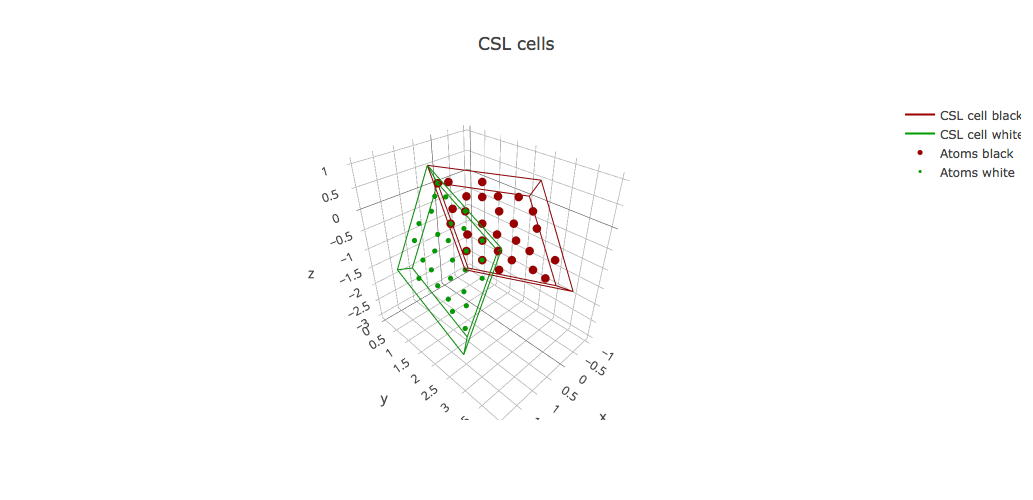

In [10]:
test_csl.visualise_3d()

Next we examine the two unit cells rotated into one another. They should coincide exactly:

----------------------------------------------------
CSL visualisation:
******************
CSL cells contain     28 black atoms,     28 white atoms



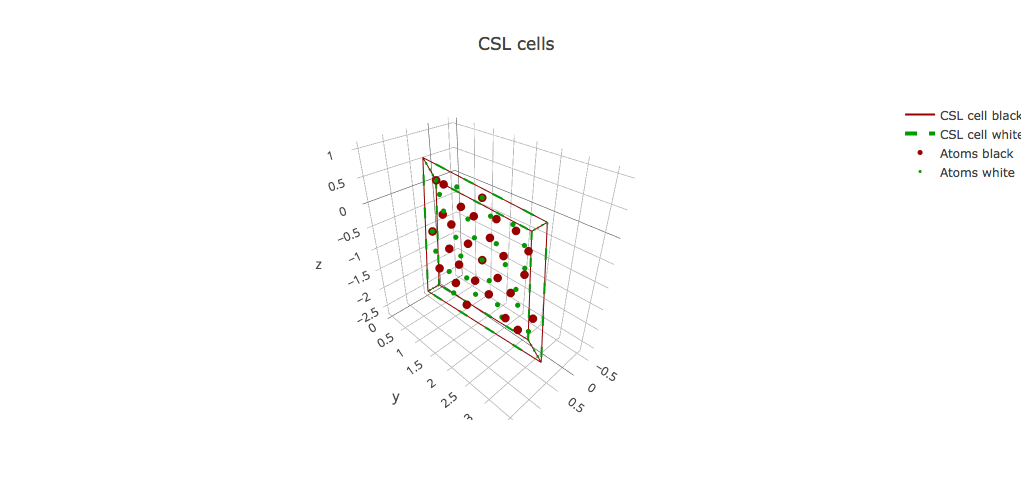

In [11]:
test_csl.visualise_3d_rotated()

Finally, we can take a look at a two-dimensional projection of the above data. The projection shown is determined by the optional argument `axis`.The default is `axis=-1` which will give a projection down the misorientation axis. Alternatively, calues of 0, 1 or 2 will gie projections down the corresponding csl unt cell vector.

----------------------------------------------------
CSL visualisation:
******************
CSL cells contain     28 black atoms,     28 white atoms



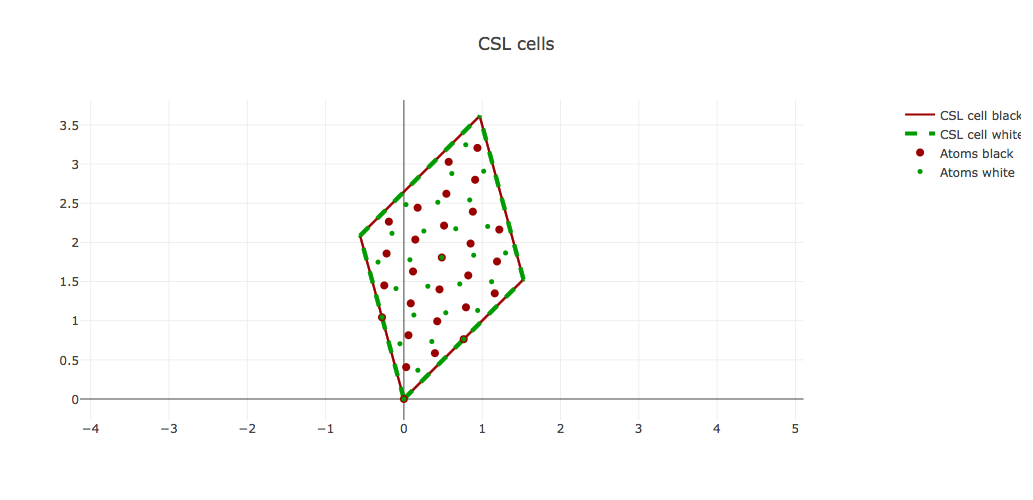

In [12]:
test_csl.visualise_2d_rotated(axis=-1)

## Calculating the DSC lattice
In order to specify the microcopic degrees of freedom of a grain boundary, we need to know the details of the DSC lattice. `csl.py` can calculate this for us as below:

In [13]:
test_csl.find_dsc_lattice()

----------------------------------------------------
csl.find_dsc_lattice() debug:
*****************************
DSC Cell fractions (and reciprocals)
[     0.071429 (   14.000000)     0.071429 (   14.000000)     0.071429 (   14.000000) ]
DSC Cell vectors (cartesian basis)
Black                                       White
[     0.071429     0.071429     0.071429]   [     0.071429     0.071429     0.071429 ]
[     0.000000     0.071429    -0.142857]   [     0.071429     0.000000    -0.142857 ]
[    -0.071429     0.142857     0.000000]   [     0.000000     0.142857    -0.071429 ]



The debug output gives the DSC lattice as fractions of the CSL unit cell vectors. By definition the reciprocals of these fractions should be integers, as for the example above.

Once we have calculated the DSC lattice, the `visualise_2d_rotated()` function will automatically include it in the visualisation output (subject to a lower bound of 0.01 on the CSL cell fractions - otherwise the plot becomes too busy):

----------------------------------------------------
CSL visualisation:
******************
CSL cells contain     28 black atoms,     28 white atoms



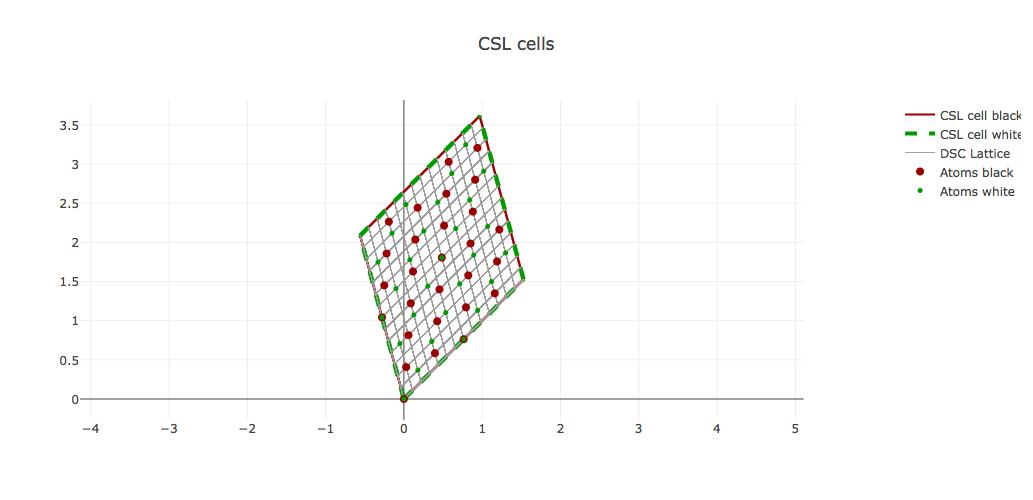

In [14]:
test_csl.visualise_2d_rotated(axis=-1)

## Creating a CSL catalogue
An important part of the functionality in `csl.py` is the ability to catalogue possible axis-angle combinations. We will demonstrate this with an example. Assume we want to consider all possible boundaries with a $[1,1,1]$ misorientation axis with fewer than some particular number of atoms in the CSL unit cell. We do this with the following function:

`write_csl_catalogue(folder, lattice_type, axis, limit, ext='df', include_basis=False)`

The function will search a range of values of `m,n` to specify possible misorientation angles. The parameters are as follows (where not self-explanatory):
* `limit` is the upper bound to the values of `m,n`
* `ext` specifies the output file type, either the default pandas dataframe (`df`), or csv (`csv`), or excel (`xlsx`)
* `include_basis` is by default `False`. The code runs much faster in this mode. Setting the value to `True` will request that the CSL unit cells be found for each misorientation and the CSL cell vectors will be included in the file.

The following example writes a full catalogue (including CSL cell vectors) for a small range of `m,n`:

In [15]:
h = 1; k = 0; l = 0
limit = 4
csl.write_csl_catalogue('catalogues/csl/', 'fcc', [h,k,l], limit, include_basis=True)

,h,k,l,m,n,theta,sigma,cos_num,cos_den,num_atoms,...,b_2[2],w_0[0],w_0[1],w_0[2],w_1[0],w_1[1],w_1[2],w_2[0],w_2[1],w_2[2]
0,1,0,0,1.0,4.0,28.072487,17.0,15.0,17.0,68.0,...,1.0,-1.0,0.0,0.0,0.0,1.0,4.0,0.0,4.0,-1.0
1,1,0,0,1.0,3.0,36.869898,5.0,4.0,5.0,20.0,...,-2.0,-1.0,0.0,0.0,0.0,-1.0,2.0,0.0,-2.0,-1.0
2,1,0,0,2.0,3.0,67.380135,13.0,5.0,13.0,52.0,...,-3.0,-1.0,0.0,0.0,0.0,-3.0,2.0,0.0,-2.0,-3.0
3,1,0,0,3.0,4.0,73.739795,25.0,7.0,25.0,100.0,...,4.0,-1.0,0.0,0.0,0.0,4.0,-3.0,0.0,3.0,4.0


We can quickly look at the output by reloading the df file. Notice that the filename for the catalogue gives details of the specification:

In [16]:
pd.read_hdf('catalogues/csl/csl_cat_full_fcc_1_0_0_limit_4.df','df')

,h,k,l,m,n,theta,sigma,cos_num,cos_den,num_atoms,...,b_2[2],w_0[0],w_0[1],w_0[2],w_1[0],w_1[1],w_1[2],w_2[0],w_2[1],w_2[2]
0,1,0,0,1.0,4.0,28.072487,17.0,15.0,17.0,68.0,...,1.0,-1.0,0.0,0.0,0.0,1.0,4.0,0.0,4.0,-1.0
1,1,0,0,1.0,3.0,36.869898,5.0,4.0,5.0,20.0,...,-2.0,-1.0,0.0,0.0,0.0,-1.0,2.0,0.0,-2.0,-1.0
2,1,0,0,2.0,3.0,67.380135,13.0,5.0,13.0,52.0,...,-3.0,-1.0,0.0,0.0,0.0,-3.0,2.0,0.0,-2.0,-3.0
3,1,0,0,3.0,4.0,73.739795,25.0,7.0,25.0,100.0,...,4.0,-1.0,0.0,0.0,0.0,4.0,-3.0,0.0,3.0,4.0


We could consider writing a much larger catalogue. This is very fast if the CSL basis is not included:

In [17]:
csl.write_csl_catalogue('catalogues/csl/', 'fcc', [1,0,0], limit=5)

,h,k,l,m,n,theta,sigma,cos_num,cos_den
0,1,0,0,1.0,5.0,22.619865,13.0,12.0,13.0
1,1,0,0,1.0,4.0,28.072487,17.0,15.0,17.0
2,1,0,0,1.0,3.0,36.869898,5.0,4.0,5.0
3,1,0,0,2.0,5.0,43.602819,29.0,21.0,29.0
4,1,0,0,3.0,4.0,73.739795,25.0,7.0,25.0
5,1,0,0,4.0,5.0,77.319617,41.0,9.0,41.0


And we can read it back in for a quick look:

In [18]:
pd.read_hdf('catalogues/csl/csl_cat_fcc_1_0_0_limit_5.df','df')

,h,k,l,m,n,theta,sigma,cos_num,cos_den
0,1,0,0,1.0,5.0,22.619865,13.0,12.0,13.0
1,1,0,0,1.0,4.0,28.072487,17.0,15.0,17.0
2,1,0,0,1.0,3.0,36.869898,5.0,4.0,5.0
3,1,0,0,2.0,5.0,43.602819,29.0,21.0,29.0
4,1,0,0,3.0,4.0,73.739795,25.0,7.0,25.0
5,1,0,0,4.0,5.0,77.319617,41.0,9.0,41.0
